# Customer Review Forecast Engine
* This model is given a dataset that contains the quanitity of reviews during certain hours of the day for unique businesses/products from Amazon and Google. From this data, the model can project how many reviews a certain business/product will get during a certain hour of the day.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error

In [ ]:
# Ensuring the correct versions of libaries are used
print("pandas version: ", pd.__version__)
print("numpy version: ", np.__version__)
print("matplotlib version: ", matplotlib.__version__)
print("tensorflow version: ", tf.__version__)

pandas version:  2.2.2
numpy version:  2.0.2
matplotlib version:  3.10.0
tensorflow version:  2.20.0


## Phase 1
- upload the data from the .csv file
- organize the data by id and date, remove any faulty rows,
- explore the data to identify any sort of trends, patterns, cycles, etc. (Exploratory Analysis)

In [ ]:
df = pd.read_csv('Amazon-Google_Reviews.csv')

# Convert the string of dates to Datetime objects
df['ds'] = pd.to_datetime(df['ds'])

# Sort by unique_id and then ds (date)
df = df.sort_values(by=['unique_id','ds'])

# Check fo missing vlaues for each column
print("Missing values per column:\n", df.isnull().sum())






Missing values per column:
 Unnamed: 0    0
ds            0
y             0
unique_id     0
dtype: int64


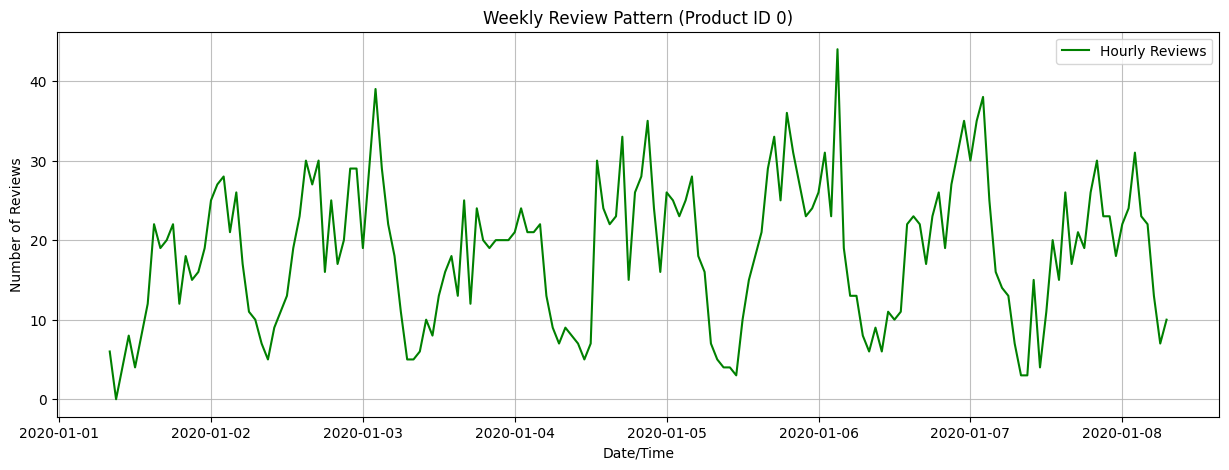

In [ ]:
# Plot the first 168 hours (7 days) for the first product (ID/Location:0)
sample = df[df['unique_id']==0].head(168)

plt.figure(figsize=(15, 5))
plt.plot(sample['ds'], sample['y'], color='green', label='Hourly Reviews')
plt.title('Weekly Review Pattern (Product ID 0)')
plt.xlabel('Date/Time')
plt.ylabel('Number of Reviews')
plt.grid(True,alpha=0.8)
plt.legend()
plt.show()


# This graphs proves that there are trends, cycles, and patterns in the data so there is something to predict

### Exploratory Data Analysis with Seasonal Decompostion


*   Performing seasonal decomposition in order to determine if there are any meaningful patterns or trends in our data before building the predicition model
* In a seasonal decompostion, time-series data is broken down inot smaller pieces which is easier to understand
  * Trend: tells us if the data is increasing, decreasing or constant over time
  * Seasonality: tells us if  something is happening on a regular basis
  * Residue: tells us the unsual parts of the data. Not part of trend or seasonality



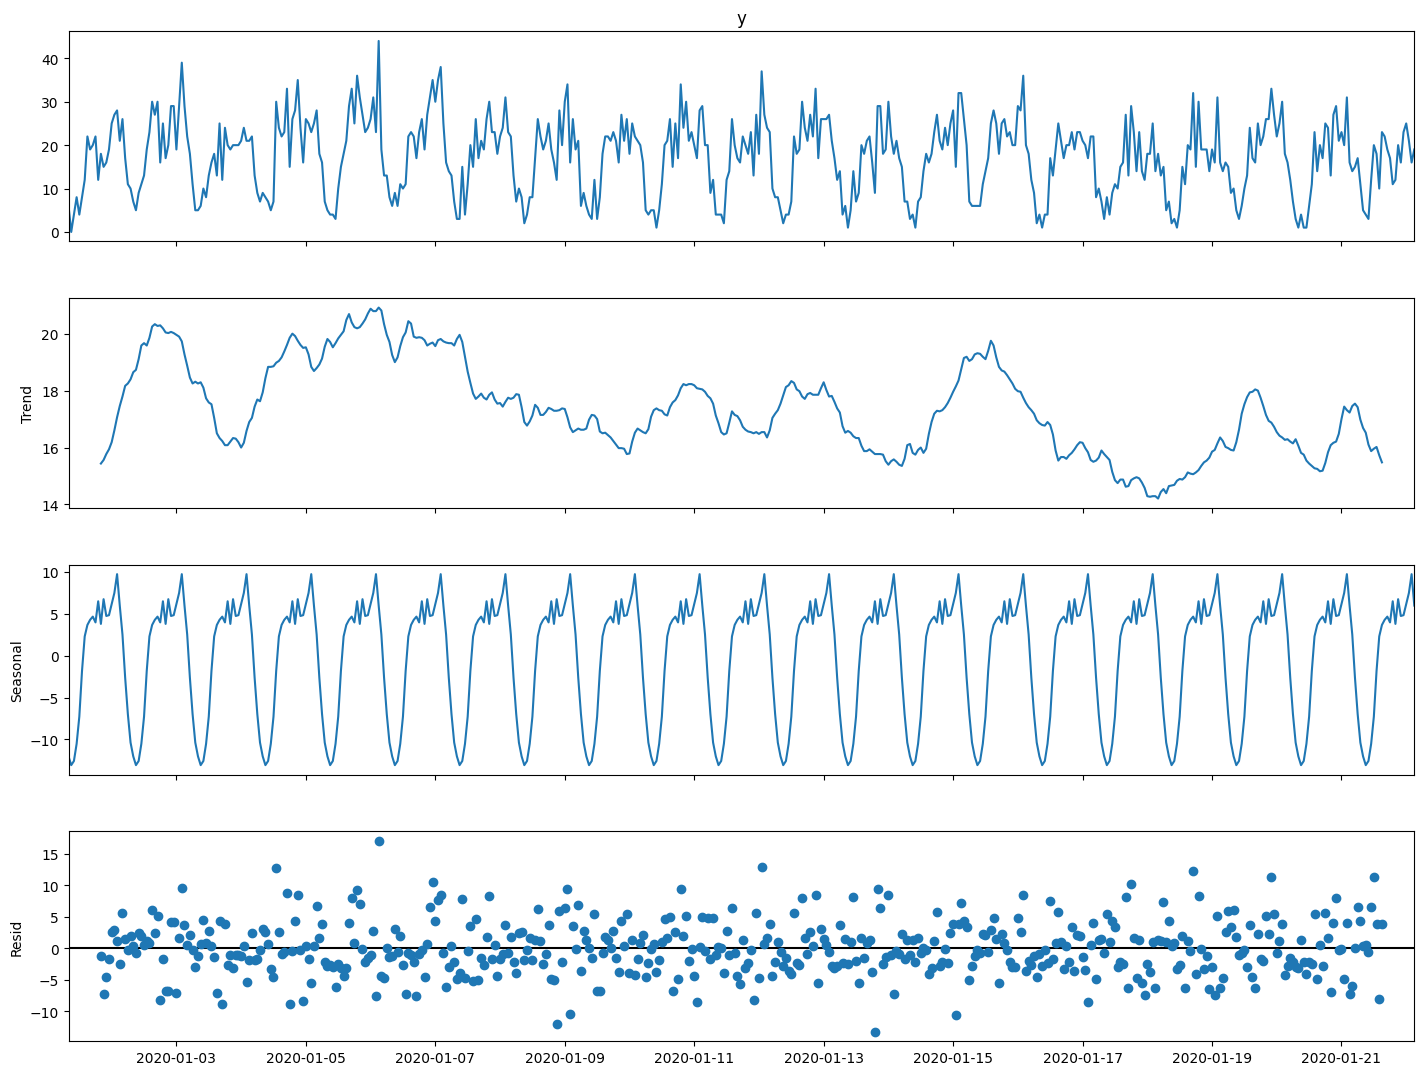

In [ ]:
# Making the 'ds' the index
# seasonal_decompose requires a time-based index to understand that rows are sequential
# Only getting product with ID of 0 because seasonal decompositon works best with one item at a time
df_0 = df[df['unique_id']==0].set_index('ds')

# Four distinct arrays of data
result = seasonal_decompose(df_0['y'].head(500), model='additive', period=24) # Using additive because in the observed seasonal spikes seem relatively constant over time

# Vizualize the graphs to show that there are trends/patterns in the data
result.plot().set_size_inches(16,12)
plt.show()

# Graphs from top to bottom: Observed, Trend, Seasonal, Residue

### Interpreting Variation in the Data
* Check for any spikes in data (viral and meaningful events) which helps train LSTM
* Calulating the standard deviation of each unique item in the dataset to see how many outliers are in the data

In [ ]:
# Calculate the the average number of reviews for each product over the past 24 hours at each point of time
df['rolling_mean'] = df.groupby('unique_id')['y'].transform(lambda x: x.rolling(window=24).mean())
# For each product, calculate how much the review total usually fluctuates over the past 24 hours
df['rolling_std'] = df.groupby('unique_id')['y'].transform(lambda x: x.rolling(window=24).std())

# Calculate Z-Score: How many standard deviations is this hour away from the average for every unique product/business?
df['z_score'] = (df['y'] - df['rolling_mean']) / df['rolling_std']

# Mark anything with a Z-score > 3 as a "Potential Surge"
surges = df[df['z_score'] > 3]
print(f"Detected {len(surges)} potential viral events in the data.")

Detected 4567 potential viral events in the data.


## Phase 2
* Encoding the time into a 24 hour clock using sine and cosine to allow the model to go from hour 23 to 0
* Get information about what happens in past by creating lags. Lags let us know what happened in the past


In [ ]:
# Get rid of rows that have missing values, go through less rows
df = df.dropna()
print(f"Cleaned data shape: {df.shape}")

# Scale the numbers between 0 and 1 since LSTM learn better with smaller numbers
scaler = MinMaxScaler()
df['y_scaled'] = scaler.fit_transform(df[['y']])
df['mean_scaled'] = scaler.fit_transform(df[['rolling_mean']])


# Use Sine and Cosine to turn time into a circle so the model does not think hours 0 and 23
# are the very far apart

# Extract the hours (0-23) from 'ds'
df['hour'] = df['ds'].dt.hour

# Convert the hours to sine and cosine
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Create a 1 hour lag in order to give the model information about what happend in the previous hour
df['lag_1'] = df.groupby('unique_id')['y_scaled'].shift(1) # Use groupby to seperate different products/locations to prevent overlap

# Create a 1 hour lag in order to give the model information about what happend in the 24 hours ago for a specific product/business
df['lag_24'] = df.groupby('unique_id')['y_scaled'].shift(24)

# Get rid of any rows with that cannot build lags
df = df.dropna().reset_index(drop=True)


Cleaned data shape: (3049593, 7)


## Phase 3
* Reshape data into 3D tensors so that the LSTM can understand the data
* Building the LSTM sequentially
* Run the model

In [ ]:

# Select features to be used in the LSTM
features = ['unique_id', 'y_scaled', 'mean_scaled', 'hour_sin', 'hour_cos', 'lag_1', 'lag_24']

# Function that tracks business IDs for every window
def create_global_windows(df, features, window_size):
    x_all, y_all, timestamps_all, ids_all = [], [], [], []

    for prod_id, group in df.groupby('unique_id'): # Isolate the business by unique_id in order to loop thorugh each business seperately
        # Convert into NumPy arrays
        data = group[features].values
        dates = group['ds'].values

        # Slide through the data with a window size of 24
        for i in range(len(data) - window_size):
            x_all.append(data[i : i + window_size]) # puting a 24 hour block of data into the current index
            y_all.append(data[i + window_size, 0])  # grab the y value from the next hour from the block above which represnts the target the model is trying to predict
            timestamps_all.append(dates[i + window_size]) # saving the ds of the target
            ids_all.append(prod_id) # Tagging the window with its business_id

    return np.array(x_all), np.array(y_all), np.array(timestamps_all), np.array(ids_all)

# Generate master tensors
X_all, y_all, target_times, business_ids_all = create_global_windows(df, features, window_size=24)

# In this part, the model will be trained with the first 60% of history from all businesses/products.
# Then, the next 20% will make the validation data.
# The last 20% will ebcoem the testing data.

# Calculate chronological cutoff points from your dataset timeline
unique_timestamps = sorted(df['ds'].unique())

# Mark places to seperate the data
t_60 = unique_timestamps[int(0.6 * len(unique_timestamps))] # 60% mark of the data
t_80 = unique_timestamps[int(0.8 * len(unique_timestamps))] # 80% mark of the data

# Split arrays using marks
train_mark = (target_times <= t_60) # First 60%
val_mark = (target_times > t_60) & (target_times <= t_80) # Next 20%
test_mark = (target_times > t_80) # Last 20%

x_train, y_train = X_all[train_mark], y_all[train_mark]
x_val, y_val = X_all[val_mark], y_all[val_mark]
x_test, y_test = X_all[test_mark], y_all[test_mark]

# Create a dedicated business ID vector for your test  to help stay organized
business_test = business_ids_all[test_mark]

### Constructing the LSTM

In [ ]:
model = Sequential([ # Sequential means build the model layer by layer

    # Layer 1: LSTM with 64 neurons.
    # input_shape tells the model: "Expect 24 hours of data with 6 variables per hour"
    LSTM(64, return_sequences=True, input_shape=(x_train.shape[1],
          x_train.shape[2])),Dropout(0.2),

    # Layer 2: LSTM picks up on higher-levl, more complex temporal combinations
    LSTM(32, return_sequences=False),
          Dropout(0.2),


    # The 0.2 Dropout prevents the model from relying on memorization


    # Layer 3: Output layer. Just 1 neuron to predict the 'y_scaled' value.
    Dense(1)
])

# Tell the model how too measure mistakes and how to improve
model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Running the LSTM and processing data sequences

In [ ]:
# Stop if the validation loss doesn't improve for 5 rounds (
early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    epochs=50, # represents a complete pass through the entire trainng dataset
    batch_size=1024,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

## Phase 4
* Converting the predictions from the model and converting them into real world metrics that can be plotted on a graph and visualized.

In [ ]:
# Convert the model's scaled decimal outputs back to real review counts
predictions_scaled = model.predict(x_test)
predictions = scaler.inverse_transform(predictions_scaled)

# Convert the true test values back for comparison
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Print your global metric
mae = mean_absolute_error(y_test_actual, predictions)
print(f"Global Mean Absolute Error across all businesses: {mae:.4f} reviews")

# Picking the first product/business to plot
target_business_id = 0

# Create a clean boolean mask comparing the tracked IDs to our target ID
business_mask = (business_test == target_business_id)

# Isolate their actual and predicted values safely
actual_single = y_test_actual[business_mask]
pred_single = predictions[business_mask]

# Plot a continuous time-series timeline for this business (e.g., first 72 hours)
if len(actual_single) > 0:
    plt.figure(figsize=(14, 6))
    plt.plot(actual_single[:72], label='Actual Hourly Reviews', color='blue', linewidth=2, alpha=0.7)
    plt.plot(pred_single[:72], label='Predicted Hourly Reviews', color='orange', linestyle='--', linewidth=2)
    plt.title(f'Hourly Review Prediction: Actual vs Predicted (Business ID {target_business_id})')
    plt.xlabel('Sequential Hours in Test Period')
    plt.ylabel('Number of Reviews')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig('business_prediction_plot.png')

    # Print localized performance for this business
    single_mae = mean_absolute_error(actual_single, pred_single)
    print(f"Business ID {target_business_id} Mean Absolute Error: {single_mae:.4f} reviews")
else:
    print(f"No records found for Business ID {target_business_id} in the test period.")

## Phase 5
* Forecasting what the next 24 hours would look like for Business 0 (the first business/product in our data)

In [ ]:
# Grab the last known 24-hour window of real test data for business with unique_id = 0
target_id = 0
business_df = df[df['unique_id'] == target_id].sort_values('ds')
last_known_window = business_df.tail(window) # Getting hte last 24 hours of data to make future prediciton

# Extract the timestamp of the last known data point to start our future clock
last_timestamp = pd.to_datetime(last_known_window['ds'].iloc[-1])

# Format the data into the 3D tensor shape the LSTM requires
current_window = last_known_window[features].values.reshape(1, window, len(features))

future_predictions = []
future_timestamps = []
current_time = last_timestamp

print(f"Starting 24-hour forecast for Business {target_id} beginning after {current_time}")

# Predict the next 24 hours sequentially
for i in range(24):

    # Move our calendar clock forward by 1 hour for this prediction step
    current_time += pd.to_timedelta(1, unit='h')
    future_timestamps.append(current_time)

    # Get the prediction
    pred_scaled = model.predict(current_window, verbose=0)[0][0]
    future_predictions.append(pred_scaled)

    # Create the new row for the next window step
    new_row = current_window[0, -1, :].copy()

    # Update Target Variable Position
    new_row[features.index('y_scaled')] = pred_scaled

    # Update Time Features: Advance the clock hands to the next hour dynamically
    next_hour = current_time.hour
    new_row[features.index('hour_sin')] = np.sin(2 * np.pi * next_hour / 24)
    new_row[features.index('hour_cos')] = np.cos(2 * np.pi * next_hour / 24)

    # Update Lags:
    new_row[features.index('lag_1')] = pred_scaled
    # The lag_24 comes from the oldest hour currently inside our 24-hour window matrix
    new_row[features.index('lag_24')] = current_window[0, 0, features.index('y_scaled')]

    # Update Rolling Mean Approximation
    new_row[features.index('mean_scaled')] = np.mean(current_window[0, :, features.index('y_scaled')])

    # Slide the window
    new_window = np.append(current_window[:, 1:, :], new_row.reshape(1, 1, len(features)), axis=1)
    current_window = new_window

# Transforms future predictions back to real human-used metrics
final_forecast_scaled = np.array(future_predictions).reshape(-1, 1)
final_forecast_actual = scaler.inverse_transform(final_forecast_scaled)

# Organize into a DataFrame
forecast_df = pd.DataFrame({
    'Timestamp': future_timestamps,
    'Predicted_Hour': [t.hour for t in future_timestamps],
    'Predicted_Reviews': [max(0, round(val[0], 2)) for val in final_forecast_actual] # round and clip negatives
})

print("\n--- 24-HOUR FUTURE FORECAST ---")
print(forecast_df)